continuation of z-score method,ismae skewed data ke outliers detect karte hai


In [20]:
import numpy as np
import pandas as pd


In [22]:
df = pd.read_csv('/content/placement123.csv')
df.shape

(1000, 3)

In [23]:
df.sample()

,cgpa,placement_exam_marks,placed
613,6.66,55.0,1


<Axes: xlabel='placement_exam_marks'>

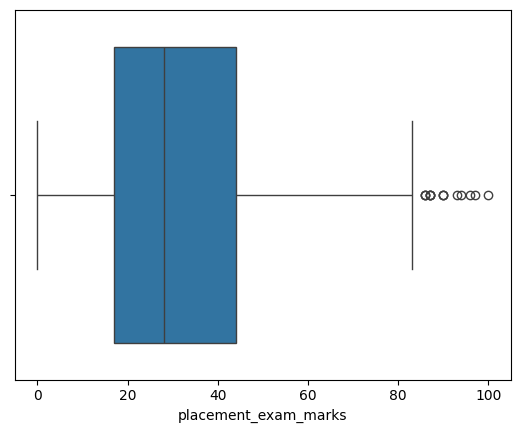

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x = df['placement_exam_marks'])

In [28]:
q1 = df['placement_exam_marks'].quantile(0.25)
q3 = df['placement_exam_marks'].quantile(0.75)
print(q1," ",q3)

17.0   44.0


In [29]:
iqr = q3 - q1
iqr

np.float64(27.0)

In [30]:
lower_limit = q1 - 1.5*iqr
upper_limit = q3 + 1.5*iqr
print(lower_limit," ",upper_limit)

-23.5   84.5


trimming

In [31]:
new_df =df[(df['placement_exam_marks']>lower_limit) & (df['placement_exam_marks']<upper_limit)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [32]:
new_df.shape

(985, 3)

capping


In [34]:
df['placement_exam_marks'] = np.where(
    df['placement_exam_marks']<lower_limit,
    lower_limit,
    np.where(
        df['placement_exam_marks']>upper_limit,
        upper_limit,
        df['placement_exam_marks']
    )
)
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: xlabel='placement_exam_marks'>

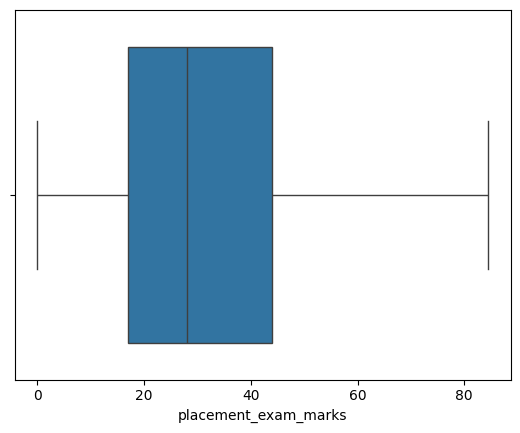

In [35]:
sns.boxplot(x = df['placement_exam_marks'])